In [1]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
import time

# connect to Google Trends
pytrends = TrendReq(hl='en-US', tz=360)
print("Connected!")

Connected!


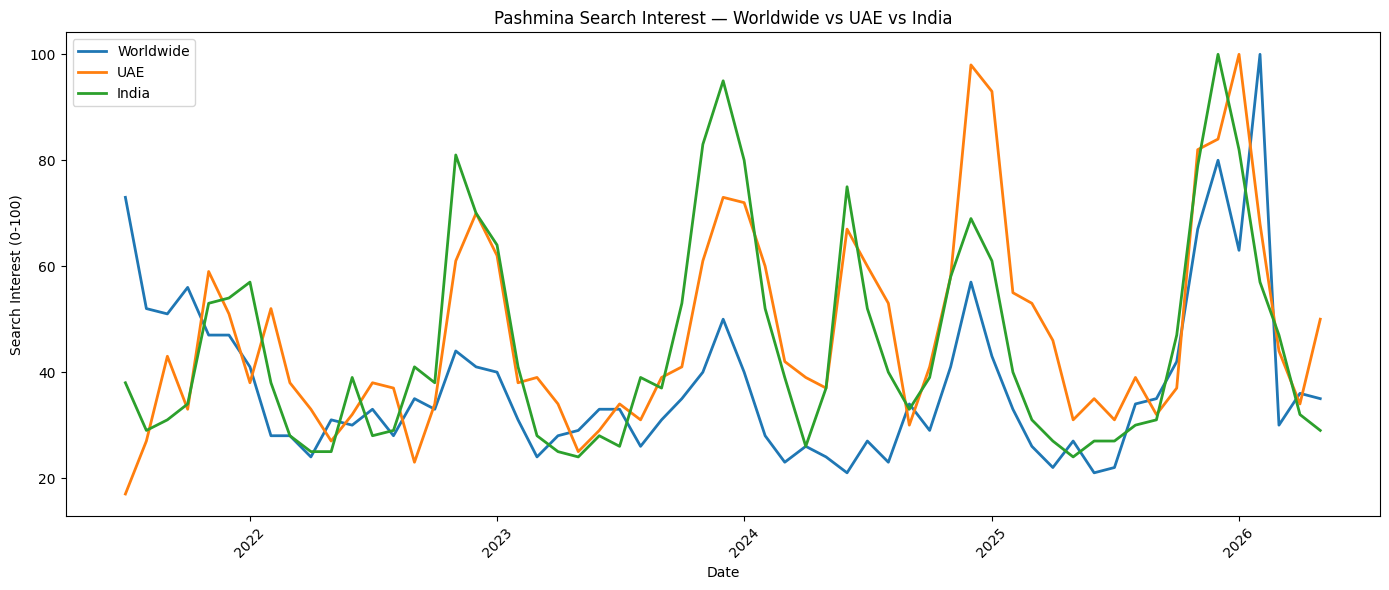

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# load all three
df_world = pd.read_csv('data/pashmina_trends.csv', skiprows=1)
df_uae = pd.read_csv('data/uae_trends.csv', skiprows=1)
df_india = pd.read_csv('data/india_trends.csv', skiprows=1)

# clean all three
for df in [df_world, df_uae, df_india]:
    df.columns = ['date', 'interest']
    
df_world['date'] = pd.to_datetime(df_world['date'])
df_uae['date'] = pd.to_datetime(df_uae['date'])
df_india['date'] = pd.to_datetime(df_india['date'])

df_world['interest'] = pd.to_numeric(df_world['interest'], errors='coerce')
df_uae['interest'] = pd.to_numeric(df_uae['interest'], errors='coerce')
df_india['interest'] = pd.to_numeric(df_india['interest'], errors='coerce')

# plot comparison
plt.figure(figsize=(14, 6))
plt.plot(df_world['date'], df_world['interest'], label='Worldwide', linewidth=2)
plt.plot(df_uae['date'], df_uae['interest'], label='UAE', linewidth=2)
plt.plot(df_india['date'], df_india['interest'], label='India', linewidth=2)

plt.title('Pashmina Search Interest — Worldwide vs UAE vs India')
plt.xlabel('Date')
plt.ylabel('Search Interest (0-100)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
# save all trends data combined
df_world['region'] = 'Worldwide'
df_uae['region'] = 'UAE'
df_india['region'] = 'India'

df_all_trends = pd.concat([df_world, df_uae, df_india], ignore_index=True)
df_all_trends.to_csv('data/trends_all_regions.csv', index=False)
print("Saved!")
print(df_all_trends.head())

Saved!
        date  interest     region
0 2021-07-01        73  Worldwide
1 2021-08-01        52  Worldwide
2 2021-09-01        51  Worldwide
3 2021-10-01        56  Worldwide
4 2021-11-01        47  Worldwide
